# Dataset Pengguna

## Import Library & Pengaturan Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style untuk grafik
sns.set_theme(style="whitegrid")

# Set random seed untuk konsistensi data
np.random.seed(42)

## Ekstraksi Data Referensi

In [2]:
# Memuat data transaksi yang sudah bersih
df_transaksi = pd.read_csv('dataset_transaksi.csv')

# Mengekstrak user_id unik
unique_users = df_transaksi['user_id'].unique()
num_users = len(unique_users)

print(f"Berhasil mengekstrak {num_users} pengguna unik dari data transaksi.")

Berhasil mengekstrak 3783 pengguna unik dari data transaksi.


## Sintesis Data

In [3]:
# 1. Umur (Fokus Gen Z: 18 - 28 tahun)
umur = np.random.randint(18, 29, size=num_users)

# 2. Pendapatan Bulanan (Rp 3.000.000 - Rp 15.000.000, kelipatan 100rb)
pendapatan = np.random.randint(30, 151, size=num_users) * 100000

# 3. Status Premium (Probabilitas: 20% Premium, 80% Regular)
status_premium = np.random.choice([True, False], size=num_users, p=[0.20, 0.80])

# 4. A/B Test Group (Distribusi 50:50 yang seimbang)
ab_test_group = np.random.choice(['A', 'B'], size=num_users, p=[0.5, 0.5])

# 5. Fitur Gamifikasi (Tema & Avatar)
tema_gratis = ['Light Mode', 'Dark Mode']
tema_premium = ['Cyberpunk Maskulin', 'Cute Hello Kitty', 'Sunset Lo-Fi', 'Midnight Galaxy']
avatar_tersedia = ['Default User', 'Crypto Ninja', 'Tech Robot', 'Finance Wizard']

tema_aktif = [np.random.choice(tema_gratis + tema_premium) if p else np.random.choice(tema_gratis) for p in status_premium]
avatar_aktif = np.random.choice(avatar_tersedia, size=num_users)

# Membangun DataFrame
df_users = pd.DataFrame({
    'user_id': unique_users,
    'umur': umur,
    'pendapatan_bulanan': pendapatan,
    'status_premium': status_premium,
    'ab_test_group': ab_test_group,
    'tema_aktif': tema_aktif,
    'avatar_aktif': avatar_aktif
})

display(df_users.head())

,user_id,umur,pendapatan_bulanan,status_premium,ab_test_group,tema_aktif,avatar_aktif
0,USER_05159,24,13600000,False,B,Light Mode,Tech Robot
1,USER_07204,21,9400000,False,B,Light Mode,Crypto Ninja
2,USER_00903,28,7800000,False,B,Light Mode,Default User
3,USER_01769,25,7600000,False,A,Light Mode,Finance Wizard
4,USER_03544,22,8100000,False,A,Light Mode,Tech Robot


## EDA Profil Pengguna

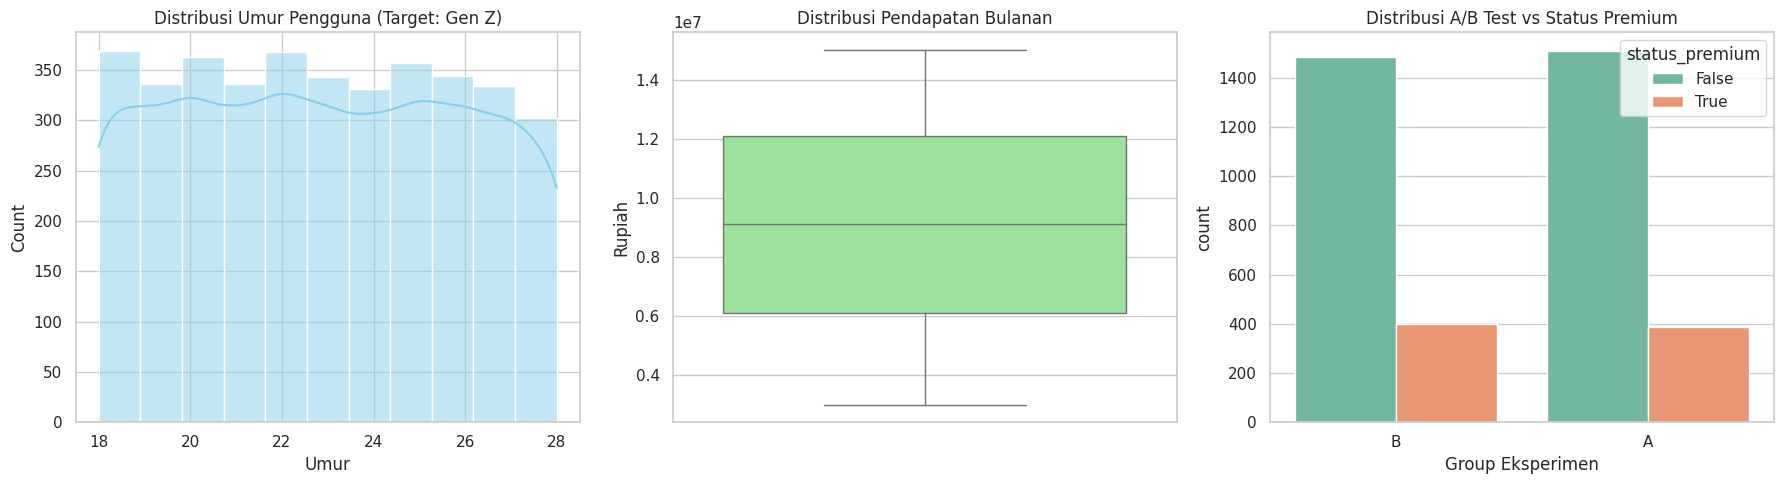

In [4]:
# Menyiapkan area plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Validasi Distribusi Umur
sns.histplot(df_users['umur'], bins=11, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribusi Umur Pengguna (Target: Gen Z)')
axes[0].set_xlabel('Umur')

# B. Validasi Distribusi Pendapatan
sns.boxplot(y=df_users['pendapatan_bulanan'], color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Pendapatan Bulanan')
axes[1].set_ylabel('Rupiah')

# C. Validasi Keseimbangan A/B Test Group
sns.countplot(data=df_users, x='ab_test_group', hue='status_premium', palette='Set2', ax=axes[2])
axes[2].set_title('Distribusi A/B Test vs Status Premium')
axes[2].set_xlabel('Group Eksperimen')

plt.tight_layout()
plt.show()

In [5]:
# Menyimpan ke format CSV
file_name = 'dataset_pengguna.csv'
df_users.to_csv(file_name, index=False)